# 01 数据清洗

In [1]:
import pandas as pd

In [2]:
pumpkins = pd.read_csv('../../2-Regression/data/US-pumpkins.csv')
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


我们感兴趣的数据是：哪一个月份的南瓜最便宜，并预测后续的价格。因此，我们需要的字段是：包装类型、月份、价格，并通过最高价格和最低价格计算出平均价格。

In [4]:
pumpkins.isnull().sum()

City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64

我们感兴趣的字段没有空值，因此所有有空值的字段都可以直接删除，由于不感兴趣的字段太多，我们直接拿感兴趣的字段建立一个新的`DataFrame`表格。

In [5]:
col = ['Package', 'Date', 'Low Price', 'High Price']

In [7]:
pumpkins_new = pd.DataFrame()
for c in col:
    pumpkins_new[c] = pumpkins[c]

In [8]:
pumpkins_new

,Package,Date,Low Price,High Price
0,24 inch bins,4/29/17,270.00,280.00
1,24 inch bins,5/6/17,270.00,280.00
2,24 inch bins,9/24/16,160.00,160.00
3,24 inch bins,9/24/16,160.00,160.00
4,24 inch bins,11/5/16,90.00,100.00
...,...,...,...,...
1752,22 lb cartons,9/30/16,14.75,14.75
1753,36 inch bins,9/26/16,275.00,275.00
1754,36 inch bins,9/27/16,275.00,275.00
1755,36 inch bins,9/28/16,275.00,275.00


计算平均价格：

In [9]:
pumpkins_new['price'] = (pumpkins_new['Low Price'] + pumpkins_new['High Price']) / 2
pumpkins_new

,Package,Date,Low Price,High Price,price
0,24 inch bins,4/29/17,270.00,280.00,275.00
1,24 inch bins,5/6/17,270.00,280.00,275.00
2,24 inch bins,9/24/16,160.00,160.00,160.00
3,24 inch bins,9/24/16,160.00,160.00,160.00
4,24 inch bins,11/5/16,90.00,100.00,95.00
...,...,...,...,...,...
1752,22 lb cartons,9/30/16,14.75,14.75,14.75
1753,36 inch bins,9/26/16,275.00,275.00,275.00
1754,36 inch bins,9/27/16,275.00,275.00,275.00
1755,36 inch bins,9/28/16,275.00,275.00,275.00


获取月份的数据

In [17]:
month = pd.DatetimeIndex(pumpkins_new['Date']).month
pumpkins_new['month'] = month
pumpkins_new.drop(columns='Date')
pumpkins_new

,Package,Date,Low Price,High Price,price,month
0,24 inch bins,4/29/17,270.00,280.00,275.00,4
1,24 inch bins,5/6/17,270.00,280.00,275.00,5
2,24 inch bins,9/24/16,160.00,160.00,160.00,9
3,24 inch bins,9/24/16,160.00,160.00,160.00,9
4,24 inch bins,11/5/16,90.00,100.00,95.00,11
...,...,...,...,...,...,...
1752,22 lb cartons,9/30/16,14.75,14.75,14.75,9
1753,36 inch bins,9/26/16,275.00,275.00,275.00,9
1754,36 inch bins,9/27/16,275.00,275.00,275.00,9
1755,36 inch bins,9/28/16,275.00,275.00,275.00,9


最后，需要统一包装秤重的度量单位：

In [18]:
pumpkins_new['Package'].value_counts()

Package
36 inch bins            663
24 inch bins            551
1/2 bushel cartons      234
1 1/9 bushel cartons    117
35 lb cartons            42
bushel cartons           37
40 lb cartons            19
1 1/9 bushel crates      17
each                     17
bins                     13
50 lb sacks              11
50 lb cartons            10
bushel baskets           10
22 lb cartons            10
20 lb cartons             6
Name: count, dtype: int64

In [22]:
pumpkins_new = pumpkins_new[pumpkins_new['Package'].str.contains('bushel', case=True, regex=True)].reset_index()
pumpkins_new

,index,Package,Date,Low Price,High Price,price,month
0,70,1 1/9 bushel cartons,9/24/16,15.00,15.0,15.000,9
1,71,1 1/9 bushel cartons,9/24/16,18.00,18.0,18.000,9
2,72,1 1/9 bushel cartons,10/1/16,18.00,18.0,18.000,10
3,73,1 1/9 bushel cartons,10/1/16,17.00,17.0,17.000,10
4,74,1 1/9 bushel cartons,10/8/16,15.00,15.0,15.000,10
...,...,...,...,...,...,...,...
410,1738,1/2 bushel cartons,9/30/16,15.00,15.0,15.000,9
411,1739,1/2 bushel cartons,9/30/16,13.75,15.0,14.375,9
412,1740,1/2 bushel cartons,9/30/16,10.75,15.0,12.875,9
413,1741,1/2 bushel cartons,9/30/16,12.00,12.0,12.000,9


In [23]:
pumpkins_new['Package'].value_counts()

Package
1/2 bushel cartons      234
1 1/9 bushel cartons    117
bushel cartons           37
1 1/9 bushel crates      17
bushel baskets           10
Name: count, dtype: int64

统一度量单位后，注意到蒲式耳重量有些是按`1/2`称，有些是`1+1/9`称，因此还需要把对应的价格统一。

In [28]:
pumpkins_new.loc[pumpkins_new['Package'].str.contains('1 1/9'), 'price'] = pumpkins_new['price'] / (1+1/9)
pumpkins_new.loc[pumpkins_new['Package'].str.contains('1/2'), 'price'] = pumpkins_new['price'] / (1/2)
pumpkins_new

,index,Package,Date,Low Price,High Price,price,month
0,70,1 1/9 bushel cartons,9/24/16,15.00,15.0,12.15,9
1,71,1 1/9 bushel cartons,9/24/16,18.00,18.0,14.58,9
2,72,1 1/9 bushel cartons,10/1/16,18.00,18.0,14.58,10
3,73,1 1/9 bushel cartons,10/1/16,17.00,17.0,13.77,10
4,74,1 1/9 bushel cartons,10/8/16,15.00,15.0,12.15,10
...,...,...,...,...,...,...,...
410,1738,1/2 bushel cartons,9/30/16,15.00,15.0,30.00,9
411,1739,1/2 bushel cartons,9/30/16,13.75,15.0,28.75,9
412,1740,1/2 bushel cartons,9/30/16,10.75,15.0,25.75,9
413,1741,1/2 bushel cartons,9/30/16,12.00,12.0,24.00,9


# 02 数据可视化

我们需要选择图表来更好的展示数据的关系。

<Axes: xlabel='month'>

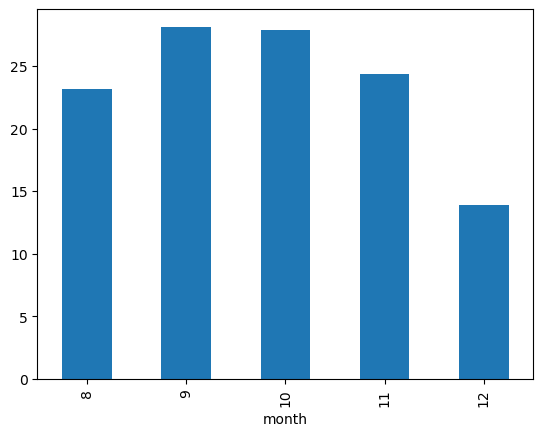

In [38]:
pumpkins_gb = pumpkins_new.groupby(['month'])
pumpkins_gb['price'].mean().plot.bar()

<Axes: ylabel='Frequency'>

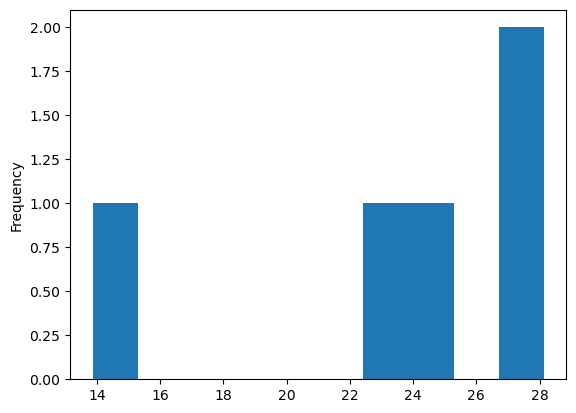

In [39]:
pumpkins_gb['price'].mean().plot.hist()

<Axes: xlabel='month'>

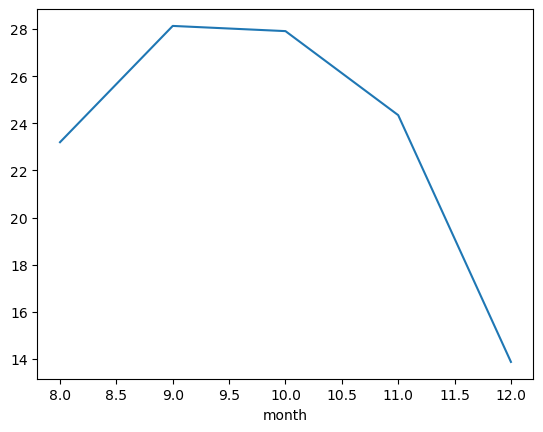

In [41]:
pumpkins_gb['price'].mean().plot()

In [50]:
import matplotlib.pyplot as plt

In [54]:
plot_x = [8, 9, 10, 11, 12]
plot_y = [pumpkins_gb['price'].mean()[i] for i in plot_x]

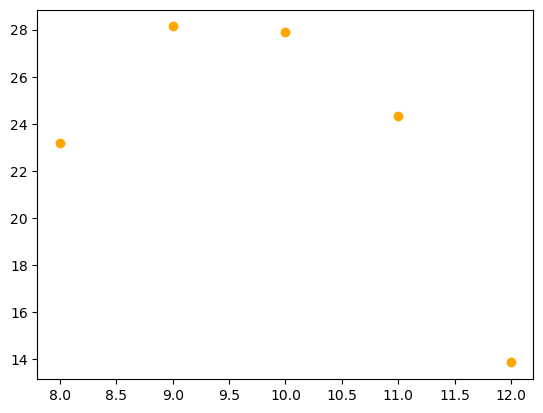

In [55]:
plt.scatter(plot_x, plot_y, color='orange')

可以看到，柱形图更能主观表现月份与价格的关系。并且12月，南瓜的价格最便宜，这与季节性的影响有关。10月的南瓜最贵，这可能与万圣节期间，南瓜装饰的需求量有关。